In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [4]:
# Load the raw dataset

df = pd.read_csv("../data/car_insurance_data.txt", sep='|')

C:\Users\USED\AppData\Local\Temp\ipykernel_19564\1418489566.py:3: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/car_insurance_data.txt", sep='|')


In [5]:
#list of separate columns like
print(df.columns.tolist()) 

['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']


In [6]:
# Show basic info
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  object 
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  object 
 5   LegalType                 1000098 non-null  object 
 6   Title                     1000098 non-null  object 
 7   Language                  1000098 non-null  object 
 8   Bank                      854137 non-null   object 
 9   AccountType               959866 non-null   object 
 10  MaritalStatus             991839 non-null   object 
 11  Gender                    990562 non-null   object 
 12  Country                   1000098 non-null  object 
 13  Province                  1

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [7]:
#Handle Missing Values
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)



NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
CustomValueEstimate         779642
WrittenOff                  641901
Converted                   641901
Rebuilt                     641901
NewVehicle                  153295
Bank                        145961
AccountType                  40232
Gender                        9536
MaritalStatus                 8259
mmcode                         552
VehicleType                    552
make                           552
VehicleIntroDate               552
NumberOfDoors                  552
bodytype                       552
kilowatts                      552
cubiccapacity                  552
Cylinders                      552
Model                          552
CapitalOutstanding               2
dtype: int64

In [8]:
# Option 1: Drop missing rows
df = df.dropna()
df['SumInsured'].fillna(df['SumInsured'].median(), inplace=True)

C:\Users\USED\AppData\Local\Temp\ipykernel_19564\3946345985.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SumInsured'].fillna(df['SumInsured'].median(), inplace=True)


In [9]:
df.describe

<bound method NDFrame.describe of Empty DataFrame
Columns: [UnderwrittenCoverID, PolicyID, TransactionMonth, IsVATRegistered, Citizenship, LegalType, Title, Language, Bank, AccountType, MaritalStatus, Gender, Country, Province, PostalCode, MainCrestaZone, SubCrestaZone, ItemType, mmcode, VehicleType, RegistrationYear, make, Model, Cylinders, cubiccapacity, kilowatts, bodytype, NumberOfDoors, VehicleIntroDate, CustomValueEstimate, AlarmImmobiliser, TrackingDevice, CapitalOutstanding, NewVehicle, WrittenOff, Rebuilt, Converted, CrossBorder, NumberOfVehiclesInFleet, SumInsured, TermFrequency, CalculatedPremiumPerTerm, ExcessSelected, CoverCategory, CoverType, CoverGroup, Section, Product, StatutoryClass, StatutoryRiskType, TotalPremium, TotalClaims]
Index: []

[0 rows x 52 columns]>

In [10]:
# Check and drop duplicate rows
print(f"Duplicates before: {df.duplicated().sum()}")
df = df.drop_duplicates()


Duplicates before: 0


In [11]:
# Remove extreme outliers beyond 99th percentile
df = df[df['TotalPremium'] <= df['TotalPremium'].quantile(0.99)]
df = df[df['SumInsured'] <= df['SumInsured'].quantile(0.99)]


In [12]:
#Remove rows with zero or negative values (if not logical)
df = df[df['TotalPremium'] > 0]
df = df[df['SumInsured'] > 0]


In [13]:
# Save cleaned data for EDA and modeling

df .to_csv("../data/cleaned_insurance_data.txt", sep='|')


In [14]:
print(df.columns.tolist()) 

['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']


In [15]:
print(os.getcwd())


g:\10 Academy\week_three_project\acis-insurance-risk-analytics\notebooks


In [17]:
df = pd.read_csv("../data/insurance_data.txt", sep='|')



C:\Users\USED\AppData\Local\Temp\ipykernel_19564\2928440660.py:1: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/insurance_data.txt", sep='|')


In [18]:
# You should see a list of separate columns like ['UnderwrittenCoverID', 'PolicyID', ..., 'TotalClaims']
print(df.columns.tolist())  


['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  object 
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  object 
 5   LegalType                 1000098 non-null  object 
 6   Title                     1000098 non-null  object 
 7   Language                  1000098 non-null  object 
 8   Bank                      854137 non-null   object 
 9   AccountType               959866 non-null   object 
 10  MaritalStatus             991839 non-null   object 
 11  Gender                    990562 non-null   object 
 12  Country                   1000098 non-null  object 
 13  Province                  1

In [20]:
df.describe()


,UnderwrittenCoverID,PolicyID,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
std,6.329371e+04,5.290039e+03,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03
min,1.000000e+00,1.400000e+01,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05


In [21]:
#Calculate Overall Loss Ratio

loss_ratio = df['TotalClaims'].sum() / df['TotalPremium'].sum()
print(f"Overall Loss Ratio: {loss_ratio:.2f}")

Overall Loss Ratio: 1.05


In [22]:
# Grouped loss ratios by Province
loss_by_province = df.groupby('Province')[['TotalClaims', 'TotalPremium']].sum()
loss_by_province['LossRatio'] = loss_by_province['TotalClaims'] / loss_by_province['TotalPremium']
print("Loss Ratio by Province:")
print(loss_by_province.sort_values(by='LossRatio', ascending=False))


Loss Ratio by Province:
                TotalClaims  TotalPremium  LossRatio
Province                                            
Gauteng        2.939415e+07  2.405377e+07   1.222018
KwaZulu-Natal  1.430138e+07  1.320908e+07   1.082693
Western Cape   1.038977e+07  9.806559e+06   1.059472
North West     5.920250e+06  7.490508e+06   0.790367
Mpumalanga     2.044675e+06  2.836292e+06   0.720897
Free State     3.549223e+05  5.213632e+05   0.680758
Limpopo        1.016477e+06  1.537324e+06   0.661199
Eastern Cape   1.356427e+06  2.140104e+06   0.633813
Northern Cape  8.949051e+04  3.165581e+05   0.282699


C:\Users\USED\AppData\Local\Temp\ipykernel_19564\780908071.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loss_by_province, x='LossRatio', y='Province', palette='coolwarm')
C:\Users\USED\AppData\Local\Temp\ipykernel_19564\780908071.py:9: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) Arial.
  plt.savefig("../reports/loss_ratio_by_province.png", dpi=300, bbox_inches='tight')
g:\10 Academy\week_three_project\acis-insurance-risk-analytics\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


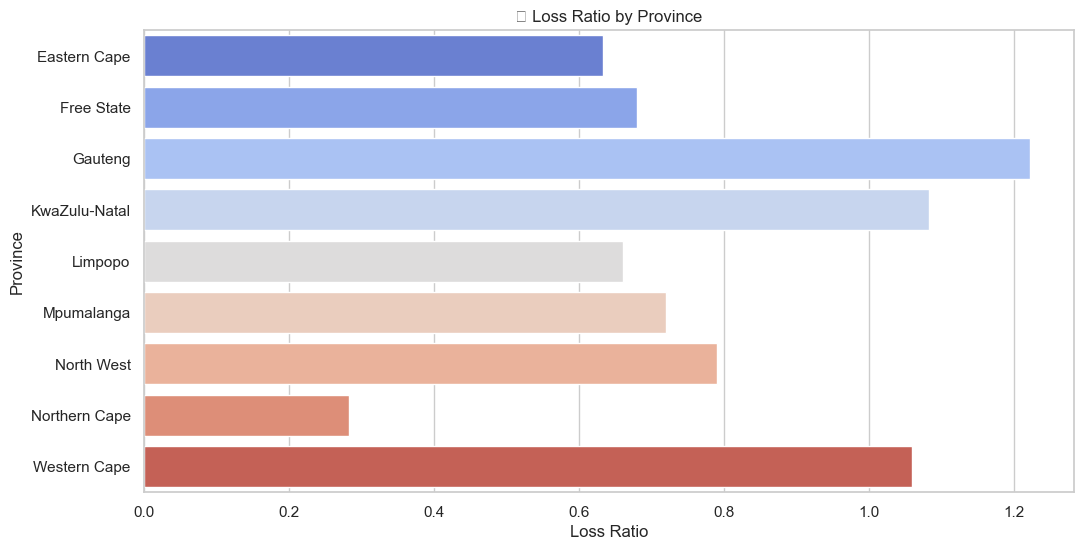

In [23]:

# ✅ Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=loss_by_province, x='LossRatio', y='Province', palette='coolwarm')
plt.title('📍 Loss Ratio by Province')
plt.xlabel('Loss Ratio')
plt.ylabel('Province')

# ✅ Save the plot to the outputs folder
plt.savefig("../reports/loss_ratio_by_province.png", dpi=300, bbox_inches='tight')

# Optional: Display the plot
plt.show()



In [24]:
loss_by_vehicle = df.groupby('VehicleType')[['TotalClaims', 'TotalPremium']].sum()
loss_by_vehicle['LossRatio'] = loss_by_vehicle['TotalClaims'] / loss_by_vehicle['TotalPremium']
print("\nLoss Ratio by VehicleType:")
print(loss_by_vehicle.sort_values(by='LossRatio', ascending=False))



Loss Ratio by VehicleType:
                    TotalClaims  TotalPremium  LossRatio
VehicleType                                             
Heavy Commercial   7.504746e+05  4.609479e+05   1.628112
Medium Commercial  4.119867e+06  3.922746e+06   1.050251
Passenger Vehicle  5.937207e+07  5.664202e+07   1.048198
Light Commercial   6.045250e+04  2.604975e+05   0.232066
Bus                7.996535e+03  5.824474e+04   0.137292


C:\Users\USED\AppData\Local\Temp\ipykernel_19564\749691069.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loss_by_vehicle, x='LossRatio', y='VehicleType', palette='viridis')
C:\Users\USED\AppData\Local\Temp\ipykernel_19564\749691069.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\USED\AppData\Local\Temp\ipykernel_19564\749691069.py:14: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.savefig("../reports/loss_ratio_by_vehicle_type.png", dpi=300, bbox_inches='tight')
g:\10 Academy\week_three_project\acis-insurance-risk-analytics\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


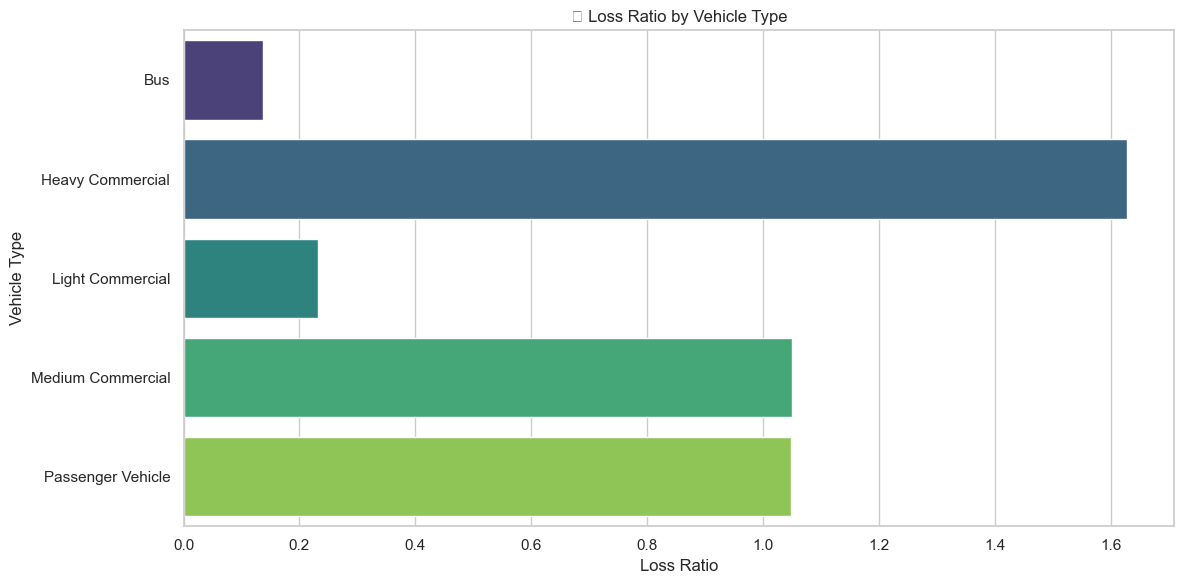

In [25]:

# Create barplot
plt.figure(figsize=(12, 6))
sns.barplot(data=loss_by_vehicle, x='LossRatio', y='VehicleType', palette='viridis')

# Titles and labels
plt.title('📉 Loss Ratio by Vehicle Type')
plt.xlabel('Loss Ratio')
plt.ylabel('Vehicle Type')

# Show plot
plt.tight_layout()

#  Save to outputs folder
plt.savefig("../reports/loss_ratio_by_vehicle_type.png", dpi=300, bbox_inches='tight')
plt.show()


In [26]:
loss_by_gender = df.groupby('Gender')[['TotalClaims', 'TotalPremium']].sum()
loss_by_gender['LossRatio'] = loss_by_gender['TotalClaims'] / loss_by_gender['TotalPremium']
print("\nLoss Ratio by Gender:")
print(loss_by_gender.sort_values(by='LossRatio', ascending=False))



Loss Ratio by Gender:
                TotalClaims  TotalPremium  LossRatio
Gender                                              
Not specified  6.271410e+07  5.920275e+07   1.059311
Male           1.396704e+06  1.580143e+06   0.883910
Female         2.502461e+05  3.044806e+05   0.821879


C:\Users\USED\AppData\Local\Temp\ipykernel_19564\1515621046.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loss_by_gender, x='Gender', y='LossRatio', palette='Set2')
C:\Users\USED\AppData\Local\Temp\ipykernel_19564\1515621046.py:11: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\USED\AppData\Local\Temp\ipykernel_19564\1515621046.py:12: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig("../reports/loss_ratio_by_gender_type.png", dpi=300, bbox_inches='tight')
g:\10 Academy\week_three_project\acis-insurance-risk-analytics\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


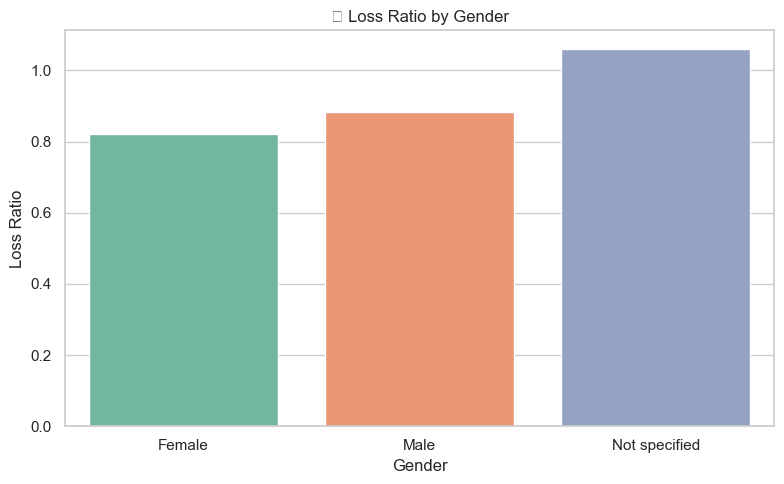

In [27]:

# Create the barplot
plt.figure(figsize=(8, 5))
sns.barplot(data=loss_by_gender, x='Gender', y='LossRatio', palette='Set2')

# Titles and labels
plt.title('📊 Loss Ratio by Gender')
plt.ylabel('Loss Ratio')
plt.xlabel('Gender')

# Show the plot
plt.tight_layout()
plt.savefig("../reports/loss_ratio_by_gender_type.png", dpi=300, bbox_inches='tight')
plt.show()

In [28]:
# Plot settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
os.makedirs("../outputs/cleaned_plots", exist_ok=True)

In [29]:
#detect outliers in a specific column of a DataFrame
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers, lower, upper



In [30]:
columns_to_check = ['TotalClaims', 'CustomValueEstimate']
outlier_summary = {}

for col in columns_to_check:
    if col in df.columns:
        outliers, lower, upper = detect_outliers_iqr(df, col)
        outlier_summary[col] = len(outliers)
        print(f"{col}: {len(outliers)} outliers detected.")

TotalClaims: 2793 outliers detected.
CustomValueEstimate: 1785 outliers detected.


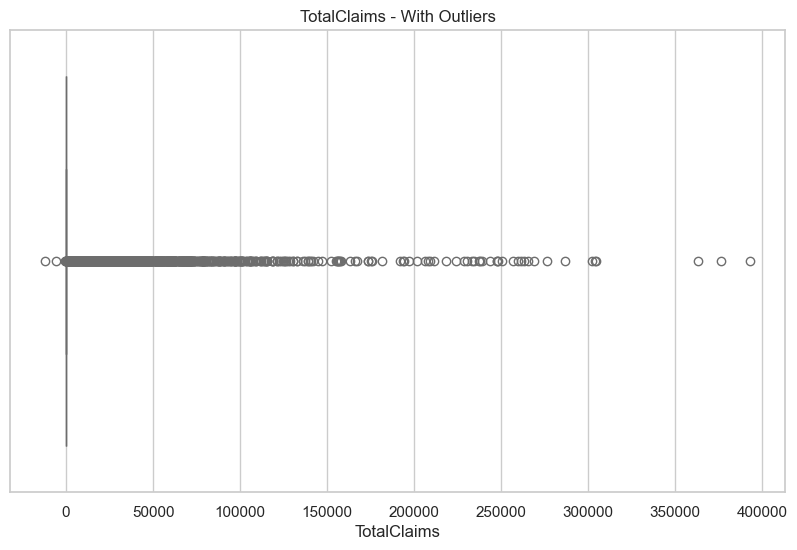

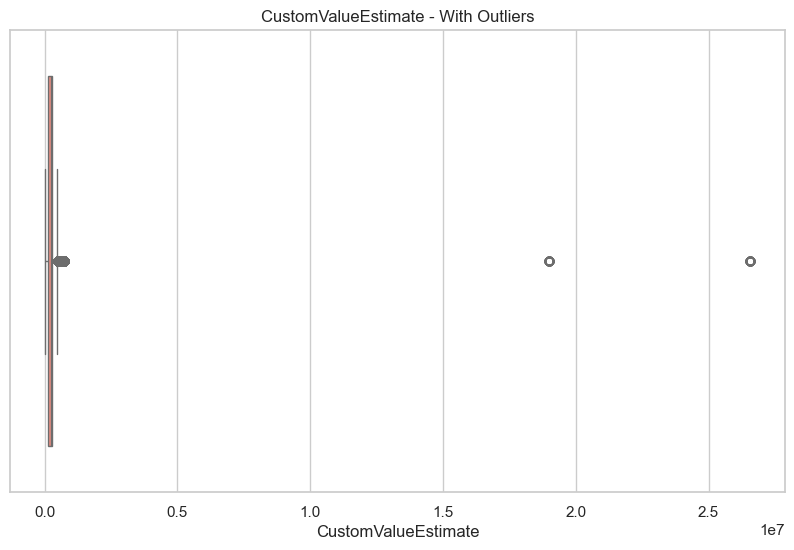

In [31]:
for col in columns_to_check:
    if col in df.columns:
        # Raw Plot
        plt.figure()
        sns.boxplot(x=df[col], color='salmon')
        plt.title(f"{col} - With Outliers")
        plt.savefig(f"../reports/TotalClaims_with_outliers.png", dpi=300, bbox_inches='tight')
        #plt.savefig("../reports/loss_ratio_by_gender_type.png", dpi=300, bbox_inches='tight')
        plt.show()
       
       

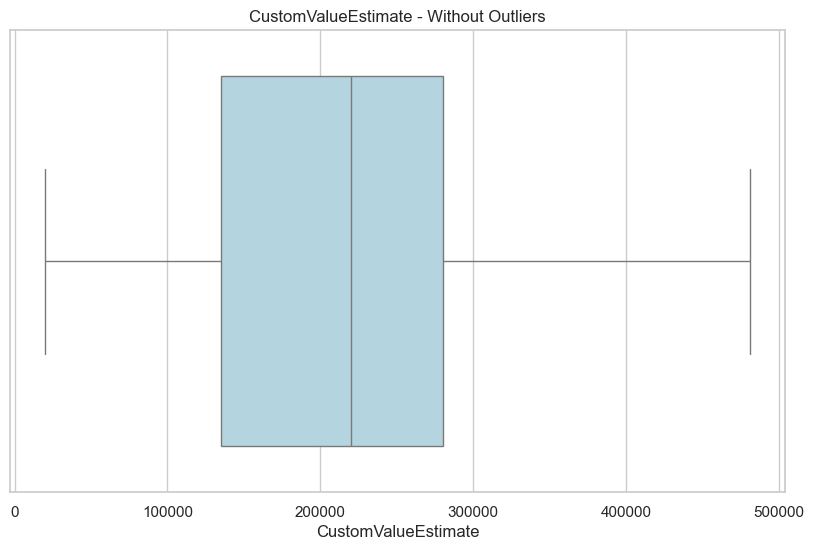

In [32]:
  # Remove outliers for visualization
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_filtered = df[(df[col] >= lower) & (df[col] <= upper)]

        
# Cleaned Plot
plt.figure()
sns.boxplot(x=df_filtered[col], color='lightblue')
plt.title(f"{col} - Without Outliers")
plt.savefig(f"../reports/CustomValueEstimate_without_outliers.png", dpi=300, bbox_inches='tight')
plt.show()
